In [74]:
import pandas as pd 
import numpy as np 

# Exploratory Data Analysis (EDA)

In [75]:
train_data = pd.read_csv('../data/liar-plus/train2.tsv', sep='\t', header=None)
train_data.columns =['index','id', 'label', 'statement', 'subject', 'speaker', 'speaker_job_title', 'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context','justification']
train_data.drop(columns=['index'], inplace=True)

test_data = pd.read_csv('../data/liar-plus/test2.tsv', sep='\t', header=None)
test_data.columns =['index','id', 'label', 'statement', 'subject', 'speaker', 'speaker_job_title', 'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context','justification']
test_data.drop(columns=['index'], inplace=True)

val_data = pd.read_csv('../data/liar-plus/val2.tsv', sep='\t', header=None)
val_data.columns =['index','id', 'label', 'statement', 'subject', 'speaker', 'speaker_job_title', 'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context','justification']
val_data.drop(columns=['index'], inplace=True)

training_data = pd.concat([train_data,test_data,val_data])
training_data.head()

,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context,justification
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer,That's a premise that he fails to back up. Ann...
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.,"Surovell said the decline of coal ""started whe..."
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver,Obama said he would have voted against the ame...
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release,The release may have a point that Mikulskis co...
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN,"Crist said that the economic ""turnaround start..."


In [76]:
training_data['state_info'].value_counts()

state_info
Texas             1260
Florida           1231
Wisconsin          900
New York           829
Illinois           692
                  ... 
Virginia             1
United Kingdom       1
China                1
Rhode island         1
Georgia              1
Name: count, Length: 84, dtype: int64

In [77]:
training_data['statement'].str.len().describe()

count    12791.000000
mean       107.281526
std         65.347525
min         11.000000
25%         73.000000
50%         99.000000
75%        133.000000
max       3300.000000
Name: statement, dtype: float64

In [78]:
training_data['party_affiliation'].value_counts()

party_affiliation
republican                      5665
democrat                        4137
none                            2181
organization                     264
independent                      180
newsmaker                         64
libertarian                       51
journalist                        49
activist                          45
columnist                         44
talk-show-host                    32
state-official                    24
labor-leader                      15
business-leader                   11
tea-party-member                  10
education-official                 3
green                              3
constitution-party                 3
government-body                    2
county-commissioner                2
liberal-party-canada               1
Moderate                           1
democratic-farmer-labor            1
ocean-state-tea-party-action       1
Name: count, dtype: int64

In [79]:
training_data['label'].value_counts()

label
half-true      2627
false          2507
mostly-true    2454
barely-true    2103
true           2053
pants-fire     1047
Name: count, dtype: int64

# Exploratory Data Visualizations

<BarContainer object of 6 artists>

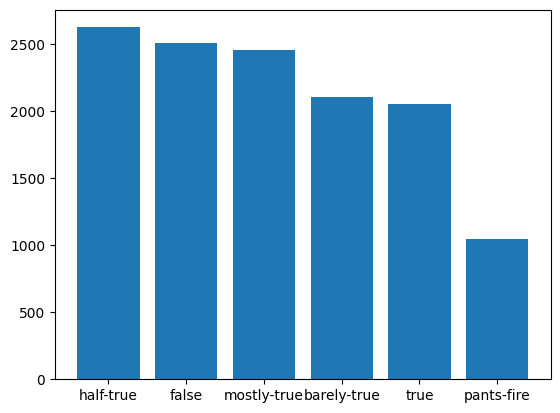

In [80]:
import matplotlib.pyplot as plt

label_data = training_data['label'].dropna().value_counts()
plt.bar(label_data.index, height=label_data)

<BarContainer object of 5 artists>

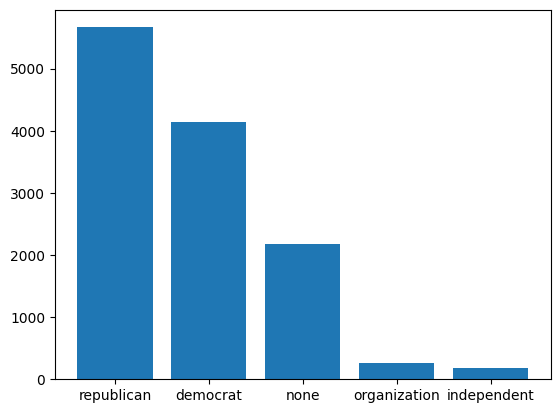

In [81]:
affiliation_data = training_data['party_affiliation'].dropna().value_counts().iloc[:5]
plt.bar(affiliation_data.index, height=affiliation_data)

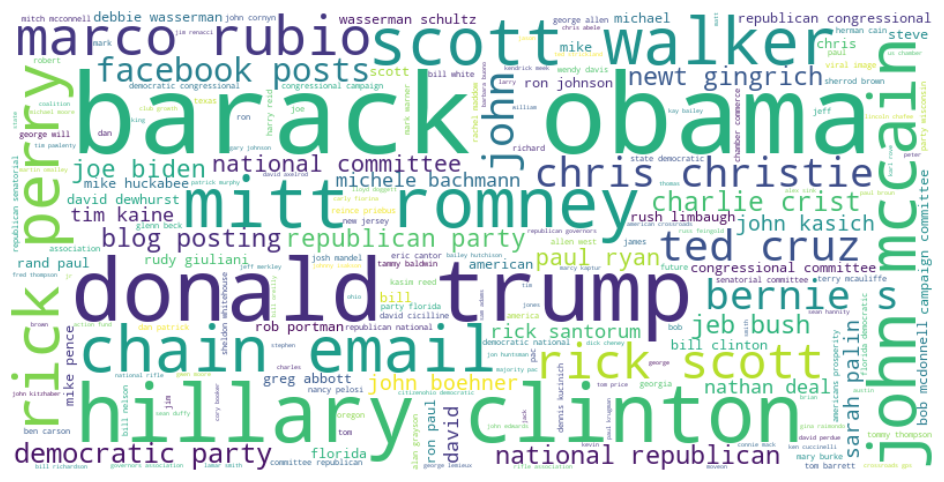

In [82]:
from wordcloud import WordCloud

speaker_str = ' '.join(training_data['speaker'].dropna().str.lower().str.strip().tolist())

# Generate word cloud
wc = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(speaker_str)

# Display
plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

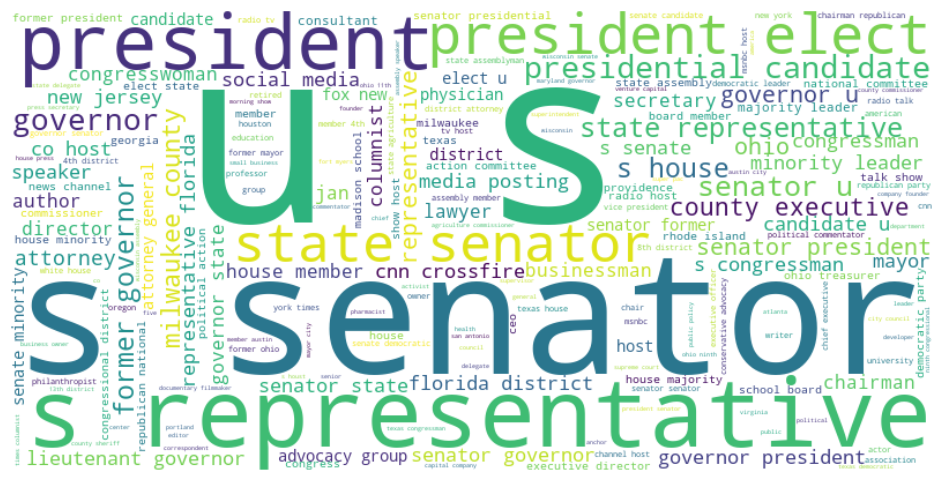

In [83]:
speaker_job_str = ' '.join(training_data['speaker_job_title'].dropna().str.lower().str.strip().tolist())

# Generate word cloud
wc = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(speaker_job_str)

# Display
plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

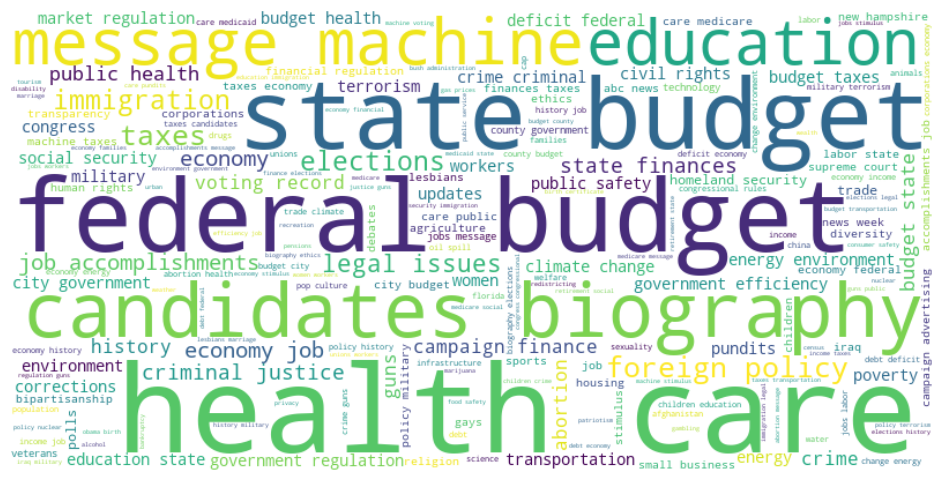

In [84]:
subject_str = ' '.join(training_data['subject'].dropna().str.lower().str.strip().apply(lambda x: ' '.join(x.split(','))).tolist())

# Generate word cloud
wc = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(subject_str)

# Display
plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

# Preliminary affiliation map (did not proceed with it)

| Label                            | Category                                                                       |
| -------------------------------- | ------------------------------------------------------------------------------ |
| **republican**                   | right-leaning                                                                  |
| **democrat**                     | left-leaning                                                                   |
| **none**                         | centrist / other (depending on usage; “none” often means no clear affiliation) |
| **organization**                 | other                                                                          |
| **independent**                  | centrist                                                                       |
| **newsmaker**                    | other                                                                          |
| **libertarian**                  | right-leaning                                                                  |
| **activist**                     | other *(activism can be left or right, context-dependent)*                     |
| **journalist**                   | other *(nominally neutral / centrist in principle)*                            |
| **columnist**                    | other *(depends on outlet or individual lean)*                                 |
| **talk-show-host**               | other *(span the spectrum; e.g., could be left or right)*                      |
| **state-official**               | other *(administrative role, not inherently partisan)*                         |
| **labor-leader**                 | left-leaning                                                                   |
| **tea-party-member**             | right-leaning                                                                  |
| **business-leader**              | right-leaning                                                                  |
| **green**                        | left-leaning                                                                   |
| **education-official**           | centrist *(typically bureaucratic / nonpartisan)*                              |
| **liberal-party-canada**         | left-leaning                                                                   |
| **government-body**              | other                                                                          |
| **Moderate**                     | centrist                                                                       |
| **democratic-farmer-labor**      | left-leaning                                                                   |
| **ocean-state-tea-party-action** | right-leaning                                                                  |
| **constitution-party**           | right-leaning                                                                  |
